# Automated registration (in-memory example)

This notebook runs pairwise enface image registration on a **SQLite in-memory** database. It mirrors what `eorm run-registration` does in production, but calls the same underlying functions (`run_patient`, `transform_from_dict`, etc.) directly so no database `.env` or CLI setup is required.

**Prerequisites:** install the ORM from `orm/` (`pip install -e .`). That pulls in [`retinalysis-registration`](https://github.com/Eyened/retinalysis-registration) (`import rtnls_registration`) for registration and transform utilities.

**Flow:**

1. Create an in-memory ORM session
2. Import two sample fundus images (with local storage mounts configured)
3. Run registration for the patient
4. Inspect stored transforms in `AttributeValue.ValueJSON`
5. Reconstruct a transform from JSON and visualize the warp (`get_red_blue` overlay)

In [1]:
from eyened_orm.utils.sqlite_testdb import create_sqlite_memory_sessionmaker

SessionLocal = create_sqlite_memory_sessionmaker(expire_on_commit=False)
session = SessionLocal()
print("Ready: in-memory SQLite database with ORM schema")

Ready: in-memory SQLite database with ORM schema


## Sample images

Download two public sample images from [retinalysis-registration](https://github.com/Eyened/retinalysis-registration) (skipped if already present under `_sample/`).

In [2]:
import os
import urllib.request

os.makedirs("_sample", exist_ok=True)

image_urls = [
    "https://github.com/Eyened/retinalysis-registration/raw/master/sample/image0.png",
    "https://github.com/Eyened/retinalysis-registration/raw/master/sample/image1.png",
]
for url in image_urls:
    filename = os.path.join("_sample", os.path.basename(url))
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)

## Import images into the in-memory database

Configure `EYENED_STORAGE_MOUNTS` so `pixel_array` can read files from this notebook directory. Both images are assigned ETDRS field **F2** and grouped into one series so registration treats them as one F2 set.

Run this notebook with working directory `orm/notebooks/` (the default when opened from that folder).

In [3]:
import json
import os
from datetime import datetime
from pathlib import Path

from eyened_orm.importer import plan_image_import, ImportRow

NOTEBOOK_DIR = Path(".").resolve()
os.environ["EYENED_STORAGE_MOUNTS"] = json.dumps({"demo-backend": str(NOTEBOOK_DIR)})

defaults = {
    "project_name": "demo-project",
    "project_external": "Y",
    "patient_identifier": "patient-1",
    "manufacturer": "UNKOWN",
    "manufacturer_model_name": "UNKOWN",
    "device_description": "UNKOWN",
    "dataset_identifier": "",
    "storage_backend_kind": "local",
    "storage_backend_key": "demo-backend",
}

rows = [
    ImportRow(
        object_key=f"_sample/image{i}.png",
        study_date=datetime.now().date(),
        modality="ColorFundus",
        laterality="L",
        etdrs_field="F2",
    )
    for i in range(2)
]

run = plan_image_import(session, rows, defaults=defaults)
run.display_summary()
run.apply()
session.commit()

Entity,Update,Create,Total
Series,,2,2
ImageInstance,,2,2
ImageStorage,,2,2
StorageBackend,,1,1
DeviceModel,,1,1
Project,,1,1
DeviceInstance,,1,1
Patient,,1,1
Study,,1,1


In [4]:
from eyened_orm import ImageInstance

ImageInstance.fetch_all(session)

[ImageInstance(ImageInstanceID=1, PublicID=e57ubkx5cv7b, SeriesID=1, SourceInfoID=None, DeviceInstanceID=1, ModalityID=None, ScanID=None, Modality=ColorFundus, SOPInstanceUid=None, SOPClassUid=None, PhotometricInterpretation=None, SamplesPerPixel=None, Rows_y=None, Columns_x=None, NrOfFrames=None, SliceThickness=None, ResolutionAxial=None, ResolutionHorizontal=None, ResolutionVertical=None, HorizontalFieldOfView=None, Laterality=L, DICOMModality=None, AnatomicRegion=None, ETDRSField=F2, Angiography=None, AcquisitionDateTime=None, PupilDilated=None, DatasetIdentifier=, AltDatasetIdentifier=None, ThumbnailPath=None, OldPath=None, FDAIdentifier=None, Inactive=False, CFROI=None, CFKeypoints=None, CFQuality=None, DateInserted=2026-05-19 15:38:16, DateModified=None, DatePreprocessed=None),
 ImageInstance(ImageInstanceID=2, PublicID=1p13rr4oa6rj, SeriesID=2, SourceInfoID=None, DeviceInstanceID=1, ModalityID=None, ScanID=None, Modality=ColorFundus, SOPInstanceUid=None, SOPClassUid=None, Photom

## Run registration

`eorm run-registration` connects to your configured database and loops over patients or projects. Here we call the same helpers the CLI uses:

- `AttributeDefinition` / `AttributesModel` for the **Registration** attribute and `retinalysis-registration` model
- `run_patient()` to compute pairwise transforms and store them on the patient

Pass `replace=True` to clear existing transforms first. Pass `skip_ids=[...]` to exclude image instance IDs (equivalent to CLI `--skip`).

In [5]:
from eyened_orm import AttributeDefinition, AttributesModel, Patient
from eyened_orm.utils.registration import run_patient

import rtnls_registration

patient = Patient.by_column(session, PatientIdentifier="patient-1")

definition = AttributeDefinition.get_or_create(
    session,
    match_by={"AttributeName": "Registration"},
    create_kwargs={"AttributeDataType": "JSON"},
)
model = AttributesModel.get_or_create(
    session,
    match_by={
        "ModelName": "retinalysis-registration",
        "Version": rtnls_registration.__version__,
    },
    create_kwargs={
        "Description": "Pairwise image registration for CFI, AF and IR",
    },
)

run_patient(session, patient, definition, model, replace=False)

Running registration for patient 1 patient-1
Found 2 enface images
Found 0 processed pairs
Running registration for F2 images
Using local storage


Running registration for 1 -> 2


## Inspect and apply registration

Stored edges link two `ImageInstanceID`s with a transform dict. Below we reconstruct the `rtnls_registration` transform object from JSON, warp `image0` into `image1` space, and overlay the result with `get_red_blue`.


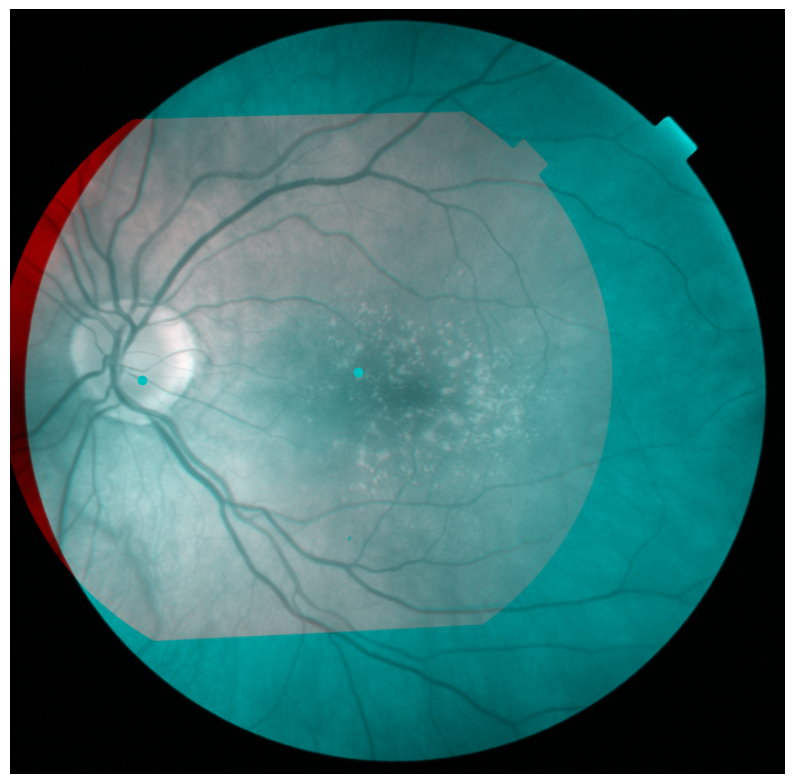

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from rtnls_registration.utils import get_red_blue

from eyened_orm import AttributeValue, ImageInstance
from eyened_orm.utils.registration import transform_from_dict

(attribute_value,) = AttributeValue.fetch_all(session)
edge = attribute_value.ValueJSON[0]

images_by_id = {img.ImageInstanceID: img for img in ImageInstance.fetch_all(session)}
im0 = images_by_id[edge["image1"]]
im1 = images_by_id[edge["image2"]]

transform = transform_from_dict(edge["transform"])

image0 = im0.pixel_array
image1 = im1.pixel_array

image0T = transform.warp(image0, image1.shape[:2])

coordinates0 = np.array([[500, 500], [900, 500]])
coordinates0T = transform.apply(coordinates0)

plt.figure(figsize=(10, 10))
plt.imshow(get_red_blue(image0T, image1))
plt.scatter(coordinates0T[:, 0], coordinates0T[:, 1], c="c")
plt.axis("off")
plt.show()